# Padrões de candles preveem o preço no curto prazo?

**Estudo estatístico com dados reais de criptomoedas** · Alessandro José dos Santos

Padrões de candles (engolfo, martelo, estrela cadente…) e cruzamentos de médias móveis são muito usados para tentar prever o próximo movimento do preço. Este estudo testa essas regras com **dados reais da Binance** e com rigor estatístico, para responder:

> **Essas regras acertam a direção do preço mais do que o acaso (50%)?**

Métodos usados: backtest, intervalo de confiança de Wilson, teste binomial com correção de Bonferroni, validação walk-forward, Brier score e autocorrelação dos retornos.

Ao final, o notebook salva os gráficos na pasta `imagens/` e **gera o `README.md` automaticamente** com os resultados.

## 1. Configuração

In [1]:
import json
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.stats import binomtest

# Ativos e período analisados
ATIVOS = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT"]
INTERVALO = "1m"           # candles de 1 minuto
CANDLES_POR_ATIVO = 10_000  # ~7 dias de candles de 1 minuto por ativo
HORIZONTES = [1, 5]         # prever o preço 1 e 5 candles à frente
ALFA = 0.05                 # nível de significância

# True = usa um passeio aleatório simulado em vez de baixar dados
# (útil para testar o notebook sem internet).
MODO_SIMULADO = False

PASTA_DADOS = Path("dados")
PASTA_IMAGENS = Path("imagens")
PASTA_DADOS.mkdir(exist_ok=True)
PASTA_IMAGENS.mkdir(exist_ok=True)

# Estilo dos gráficos
COR_TEXTO, COR_NEUTRA, COR_DESTAQUE, COR_ALERTA = "#14232E", "#8A99A3", "#0E7C86", "#C2410C"
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#B8C4C9", "axes.labelcolor": COR_TEXTO,
    "xtick.color": COR_TEXTO, "ytick.color": COR_NEUTRA,
})

## 2. Coleta dos dados
Os candles vêm da API pública de dados de mercado da Binance (não precisa de cadastro nem chave). Cada ativo é baixado em lotes de 1.000 candles e salvo em `dados/`, para não precisar baixar de novo.

In [2]:
URL_BINANCE = "https://data-api.binance.vision/api/v3/klines"


def baixar_candles(simbolo, intervalo=INTERVALO, total=CANDLES_POR_ATIVO):
    """Baixa os últimos `total` candles de um ativo, voltando no tempo em lotes de 1.000."""
    arquivo = PASTA_DADOS / f"{simbolo}_{intervalo}.csv"
    if arquivo.exists():
        return pd.read_csv(arquivo, parse_dates=["abertura"])

    lotes, fim = [], None
    while sum(len(l) for l in lotes) < total:
        params = {"symbol": simbolo, "interval": intervalo, "limit": 1000}
        if fim is not None:
            params["endTime"] = fim
        resposta = requests.get(URL_BINANCE, params=params, timeout=30)
        resposta.raise_for_status()
        lote = resposta.json()
        if not lote:
            break
        lotes.insert(0, lote)
        fim = lote[0][0] - 1  # próximo lote termina antes do primeiro candle deste
        time.sleep(0.2)       # respeita o limite de requisições da API

    linhas = [c for lote in lotes for c in lote][-total:]
    df = pd.DataFrame(linhas).iloc[:, :6]
    df.columns = ["abertura", "open", "high", "low", "close", "volume"]
    df["abertura"] = pd.to_datetime(df["abertura"], unit="ms")
    df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].astype(float)
    df.to_csv(arquivo, index=False)
    return df


def simular_candles(simbolo, total=CANDLES_POR_ATIVO, semente=None):
    """Gera candles a partir de um passeio aleatório (sem nenhum padrão previsível)."""
    rng = np.random.default_rng(semente if semente is not None else abs(hash(simbolo)) % 2**32)
    close = 100 * np.exp(np.cumsum(rng.normal(0, 0.001, total)))
    open_ = np.r_[close[0], close[:-1]]
    ruido = np.abs(rng.normal(0, 0.0007, (2, total))) * close
    high = np.maximum(open_, close) + ruido[0]
    low = np.minimum(open_, close) - ruido[1]
    abertura = pd.date_range("2026-01-01", periods=total, freq="min")
    return pd.DataFrame({"abertura": abertura, "open": open_, "high": high, "low": low,
                         "close": close, "volume": rng.uniform(1, 100, total)})


dados = {}
for ativo in ATIVOS:
    dados[ativo] = simular_candles(ativo) if MODO_SIMULADO else baixar_candles(ativo)
    df = dados[ativo]
    print(f"{ativo}: {len(df):,} candles · {df['abertura'].min():%d/%m/%Y %H:%M} até {df['abertura'].max():%d/%m/%Y %H:%M}")

BTCUSDT: 10,000 candles · 24/09/2026 07:56 até 01/10/2026 06:35
ETHUSDT: 10,000 candles · 24/09/2026 07:56 até 01/10/2026 06:35
BNBUSDT: 10,000 candles · 24/09/2026 07:56 até 01/10/2026 06:35
SOLUSDT: 10,000 candles · 24/09/2026 07:57 até 01/10/2026 06:36
XRPUSDT: 10,000 candles · 24/09/2026 07:57 até 01/10/2026 06:36


## 3. As regras testadas
Cada regra gera um **sinal** no fechamento de um candle: `+1` (aposta que o preço vai subir), `-1` (aposta que vai cair) ou `0` (sem sinal).

| Regra | Sinal | Lógica |
|---|---|---|
| Engolfo de alta | +1 | Candle de alta que "engole" o corpo do candle de baixa anterior |
| Engolfo de baixa | −1 | O inverso do engolfo de alta |
| Martelo | +1 | Sombra inferior longa depois de uma queda |
| Estrela cadente | −1 | Sombra superior longa depois de uma alta |
| Três soldados | +1 | Três candles de alta seguidos, com fechamentos crescentes |
| Três corvos | −1 | Três candles de baixa seguidos, com fechamentos decrescentes |
| Cruzamento de médias | ±1 | Média móvel exponencial de 9 cruza a de 21 |
| Aleatório (controle) | ±1 | Direção sorteada, para comparação |

In [3]:
def gerar_sinais(df, semente=42):
    o, h, l, c = df["open"], df["high"], df["low"], df["close"]
    corpo = c - o
    corpo_abs = corpo.abs()
    sombra_sup = h - np.maximum(o, c)
    sombra_inf = np.minimum(o, c) - l
    caiu_antes = c.shift(1) < c.shift(4)   # tendência de queda nos 3 candles anteriores
    subiu_antes = c.shift(1) > c.shift(4)  # tendência de alta nos 3 candles anteriores

    sinais = pd.DataFrame(index=df.index)
    sinais["Engolfo de alta"] = np.where(
        (corpo.shift(1) < 0) & (corpo > 0) & (c >= o.shift(1)) & (o <= c.shift(1)), 1, 0)
    sinais["Engolfo de baixa"] = np.where(
        (corpo.shift(1) > 0) & (corpo < 0) & (c <= o.shift(1)) & (o >= c.shift(1)), -1, 0)
    sinais["Martelo"] = np.where(
        (corpo_abs > 0) & (sombra_inf >= 2 * corpo_abs) & (sombra_sup <= 0.3 * corpo_abs) & caiu_antes, 1, 0)
    sinais["Estrela cadente"] = np.where(
        (corpo_abs > 0) & (sombra_sup >= 2 * corpo_abs) & (sombra_inf <= 0.3 * corpo_abs) & subiu_antes, -1, 0)
    alta = corpo > 0
    baixa = corpo < 0
    sinais["Três soldados"] = np.where(
        alta & alta.shift(1, fill_value=False) & alta.shift(2, fill_value=False)
        & (c > c.shift(1)) & (c.shift(1) > c.shift(2)), 1, 0)
    sinais["Três corvos"] = np.where(
        baixa & baixa.shift(1, fill_value=False) & baixa.shift(2, fill_value=False)
        & (c < c.shift(1)) & (c.shift(1) < c.shift(2)), -1, 0)

    ema9 = c.ewm(span=9, adjust=False).mean()
    ema21 = c.ewm(span=21, adjust=False).mean()
    acima = (ema9 > ema21).astype(int)
    cruzou = acima.diff()
    sinais["Cruzamento de médias"] = np.where(cruzou == 1, 1, np.where(cruzou == -1, -1, 0))

    # Controle: direção sorteada. Cada ativo usa uma semente diferente,
    # para que os sorteios sejam independentes entre os ativos.
    rng = np.random.default_rng(semente)
    sorteio = rng.random(len(df)) < 0.05
    sinais["Aleatório (controle)"] = np.where(sorteio, rng.choice([-1, 1], len(df)), 0)

    sinais.iloc[:25] = 0  # ignora o início, sem histórico suficiente para as médias
    return sinais


REGRAS = list(gerar_sinais(dados[ATIVOS[0]].head(50)).columns)

## 4. Backtest
Para cada sinal, comparamos o preço de fechamento no momento do sinal com o fechamento `H` candles depois. O sinal **acerta** se o preço andou na direção prevista. Empates (preço igual) são descartados.

In [4]:
operacoes = []
for i, (ativo, df) in enumerate(dados.items()):
    sinais = gerar_sinais(df, semente=100 + i)
    for H in HORIZONTES:
        futuro = df["close"].shift(-H)
        variacao = np.sign(futuro - df["close"])
        for regra in REGRAS:
            s = sinais[regra]
            mask = (s != 0) & futuro.notna() & (variacao != 0)
            operacoes.append(pd.DataFrame({
                "ativo": ativo, "regra": regra, "horizonte": H,
                "momento": df.loc[mask, "abertura"].values,
                "acertou": (s[mask] == variacao[mask]).astype(int).values,
            }))
operacoes = pd.concat(operacoes, ignore_index=True)
print(f"{len(operacoes):,} sinais testados")
operacoes.head()

51,742 sinais testados


,ativo,regra,horizonte,momento,acertou
0,BTCUSDT,Engolfo de alta,1,2026-09-24 08:25:00,0
1,BTCUSDT,Engolfo de alta,1,2026-09-24 08:40:00,0
2,BTCUSDT,Engolfo de alta,1,2026-09-24 08:53:00,1
3,BTCUSDT,Engolfo de alta,1,2026-09-24 09:05:00,0
4,BTCUSDT,Engolfo de alta,1,2026-09-24 09:09:00,0


## 5. Taxa de acerto com intervalo de confiança e teste de significância
- **Intervalo de Wilson (95%)**: a faixa em que a taxa de acerto real provavelmente está. Se a faixa inclui 50%, a regra não se diferencia do acaso.
- **Teste binomial**: a probabilidade de obter esse resultado por pura sorte, se a regra fosse um cara ou coroa (p-valor).
- **Correção de Bonferroni**: como testamos muitas regras ao mesmo tempo, algumas pareceriam "boas" só por sorte. A correção exige um p-valor menor para compensar.

In [5]:
def wilson(acertos, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = acertos / n
    d = 1 + z**2 / n
    centro = p + z**2 / (2 * n)
    margem = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return ((centro - margem) / d, (centro + margem) / d)


linhas = []
for (regra, H), g in operacoes.groupby(["regra", "horizonte"], sort=False):
    n, acertos = len(g), int(g["acertou"].sum())
    ic = wilson(acertos, n)
    linhas.append({"regra": regra, "horizonte": H, "sinais": n, "acertos": acertos,
                   "taxa": acertos / n, "ic_inf": ic[0], "ic_sup": ic[1],
                   "p_valor": binomtest(acertos, n, 0.5).pvalue})
resultados = pd.DataFrame(linhas)

n_testes = len(resultados)
alfa_corrigido = ALFA / n_testes
resultados["significativo"] = resultados["p_valor"] < alfa_corrigido
resultados["acima_do_acaso"] = resultados["significativo"] & (resultados["taxa"] > 0.5)

print(f"{n_testes} testes · nível de significância corrigido (Bonferroni): {alfa_corrigido:.4f}")
(resultados.style
    .format({"taxa": "{:.1%}", "ic_inf": "{:.1%}", "ic_sup": "{:.1%}", "p_valor": "{:.4f}"})
    .hide(axis="index"))

16 testes · nível de significância corrigido (Bonferroni): 0.0031


regra,horizonte,sinais,acertos,taxa,ic_inf,ic_sup,p_valor,significativo,acima_do_acaso
Engolfo de alta,1,3776,1903,50.4%,48.8%,52.0%,0.6370,False,False
Engolfo de baixa,1,3890,2010,51.7%,50.1%,53.2%,0.0386,False,False
Martelo,1,913,507,55.5%,52.3%,58.7%,0.0009,True,True
Estrela cadente,1,906,451,49.8%,46.5%,53.0%,0.9206,False,False
Três soldados,1,5872,3144,53.5%,52.3%,54.8%,0.0000,True,True
Três corvos,1,5483,2880,52.5%,51.2%,53.8%,0.0002,True,True
Cruzamento de médias,1,2264,1181,52.2%,50.1%,54.2%,0.0415,False,False
Aleatório (controle),1,2405,1199,49.9%,47.9%,51.9%,0.9026,False,False
Engolfo de alta,5,3899,1941,49.8%,48.2%,51.4%,0.7978,False,False
Engolfo de baixa,5,3991,2007,50.3%,48.7%,51.8%,0.7277,False,False


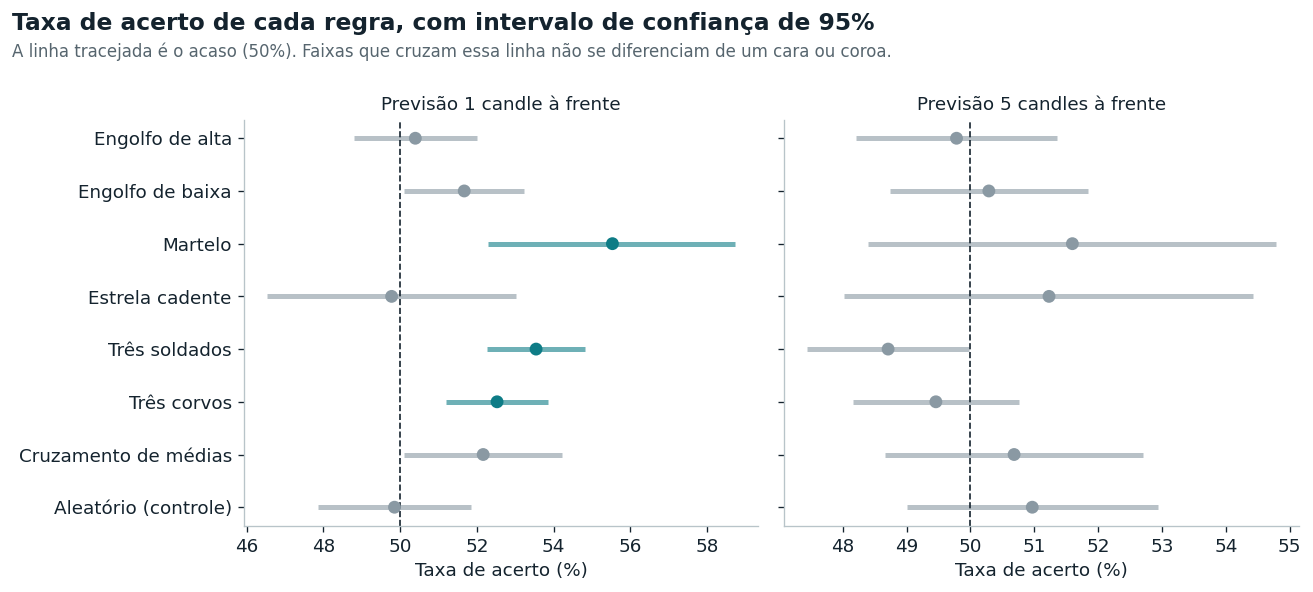

In [6]:
fig, axes = plt.subplots(1, len(HORIZONTES), figsize=(11, 5), sharey=True)
for ax, H in zip(np.atleast_1d(axes), HORIZONTES):
    r = resultados[resultados["horizonte"] == H].iloc[::-1]
    y = np.arange(len(r))
    cores = [COR_DESTAQUE if a else (COR_ALERTA if (s and t < .5) else COR_NEUTRA)
             for a, s, t in zip(r["acima_do_acaso"], r["significativo"], r["taxa"])]
    ax.hlines(y, r["ic_inf"] * 100, r["ic_sup"] * 100, color=cores, lw=3, alpha=.6)
    ax.scatter(r["taxa"] * 100, y, color=cores, s=45, zorder=3)
    ax.axvline(50, color=COR_TEXTO, lw=1, ls="--")
    ax.set_yticks(y, r["regra"])
    ax.tick_params(axis="y", colors=COR_TEXTO)
    ax.set_title(f"Previsão {H} candle{'s' if H > 1 else ''} à frente", fontsize=11, color=COR_TEXTO)
    ax.set_xlabel("Taxa de acerto (%)")
fig.suptitle("Taxa de acerto de cada regra, com intervalo de confiança de 95%",
             x=0.01, ha="left", fontsize=14, fontweight="bold", color=COR_TEXTO)
fig.text(0.01, 0.905, "A linha tracejada é o acaso (50%). Faixas que cruzam essa linha não se diferenciam de um cara ou coroa.",
         fontsize=10, color="#56656E")
fig.tight_layout()
fig.subplots_adjust(top=0.8)
fig.savefig(PASTA_IMAGENS / "taxa_acerto.png")
plt.show()

## 6. Validação walk-forward
Uma regra pode parecer boa na média e ter funcionado só em um período específico. Aqui o histórico é dividido em **3 períodos cronológicos** e a taxa de acerto é medida em cada um. Uma vantagem real deveria se manter acima de 50% nos três.

periodo,Início,Meio,Fim,estavel_acima_50
regra,,,,
Engolfo de alta,50.2%,51.0%,50.0%,False
Engolfo de baixa,52.1%,52.7%,50.2%,True
Martelo,52.6%,53.4%,60.5%,True
Estrela cadente,48.0%,48.7%,52.6%,False
Três soldados,52.7%,55.4%,52.6%,True
Três corvos,50.5%,53.5%,53.6%,True
Cruzamento de médias,52.1%,54.8%,49.7%,False
Aleatório (controle),50.6%,50.7%,48.3%,False


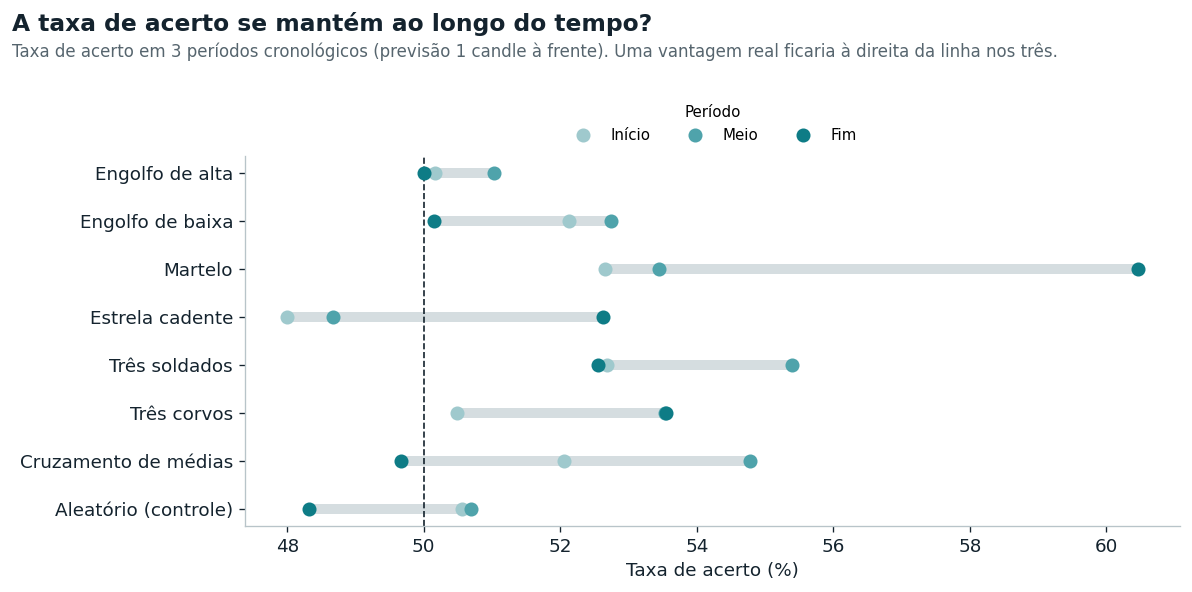

In [7]:
posicao = operacoes.groupby(["ativo", "regra", "horizonte"])["momento"].rank(method="first", pct=True)
operacoes["periodo"] = pd.cut(posicao, [0, 1 / 3, 2 / 3, 1], labels=["Início", "Meio", "Fim"])
walk = (operacoes[operacoes["horizonte"] == HORIZONTES[0]]
        .groupby(["regra", "periodo"], observed=True)["acertou"].mean().unstack().reindex(REGRAS))
walk["estavel_acima_50"] = (walk[["Início", "Meio", "Fim"]] > 0.5).all(axis=1)
display(walk.style.format({"Início": "{:.1%}", "Meio": "{:.1%}", "Fim": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(10, 5))
tabela_wf = walk[["Início", "Meio", "Fim"]].iloc[::-1]
y = np.arange(len(tabela_wf))
cores_periodo = {"Início": "#9FC9CD", "Meio": "#4FA3AB", "Fim": COR_DESTAQUE}
ax.hlines(y, tabela_wf.min(axis=1) * 100, tabela_wf.max(axis=1) * 100, color="#D5DDE0", lw=6, zorder=1)
for periodo, cor in cores_periodo.items():
    ax.scatter(tabela_wf[periodo] * 100, y, s=55, color=cor, label=periodo, zorder=3)
ax.axvline(50, color=COR_TEXTO, lw=1, ls="--")
ax.set_yticks(y, tabela_wf.index)
ax.tick_params(axis="y", colors=COR_TEXTO)
ax.set_xlabel("Taxa de acerto (%)")
ax.legend(title="Período", ncol=3, frameon=False, loc="lower center", bbox_to_anchor=(.5, 1.0), fontsize=9, title_fontsize=9)
fig.suptitle("A taxa de acerto se mantém ao longo do tempo?", x=0.01, ha="left",
             fontsize=14, fontweight="bold", color=COR_TEXTO)
fig.text(0.01, 0.905, f"Taxa de acerto em 3 períodos cronológicos (previsão {HORIZONTES[0]} candle à frente). Uma vantagem real ficaria à direita da linha nos três.",
         fontsize=10, color="#56656E")
fig.tight_layout()
fig.subplots_adjust(top=0.74)
fig.savefig(PASTA_IMAGENS / "walk_forward.png")
plt.show()

## 7. Brier score: a "confiança" da regra tem valor?
Uma ferramenta de sinais costuma mostrar uma confiança, como "este padrão acerta 58%". Para testar se esse número tem valor, ele é **calculado na primeira metade dos dados** e **avaliado na segunda metade**, que a regra nunca viu.

O Brier score mede o erro dessa previsão: **0,25 é o resultado de sempre dizer 50%**. Um valor maior que 0,25 significa que a "confiança" atrapalha em vez de ajudar.

In [8]:
brier = []
for (regra, H), g in operacoes.groupby(["regra", "horizonte"], sort=False):
    g = g.sort_values("momento")
    corte = len(g) // 2
    treino, teste = g.iloc[:corte], g.iloc[corte:]
    p = treino["acertou"].mean()
    b = ((p - teste["acertou"]) ** 2).mean()
    brier.append({"regra": regra, "horizonte": H, "confianca_estimada": p,
                  "acerto_fora_da_amostra": teste["acertou"].mean(),
                  "brier": b, "melhor_que_50": b < 0.25})
brier = pd.DataFrame(brier)
display(brier.style.format({"confianca_estimada": "{:.1%}", "acerto_fora_da_amostra": "{:.1%}", "brier": "{:.4f}"})
        .hide(axis="index"))

regra,horizonte,confianca_estimada,acerto_fora_da_amostra,brier,melhor_que_50
Engolfo de alta,1,50.7%,50.1%,0.2500,False
Engolfo de baixa,1,52.0%,51.3%,0.2499,True
Martelo,1,53.3%,57.8%,0.2460,True
Estrela cadente,1,48.8%,50.8%,0.2503,False
Três soldados,1,53.8%,53.2%,0.2490,True
Três corvos,1,51.5%,53.5%,0.2492,True
Cruzamento de médias,1,53.4%,51.0%,0.2505,False
Aleatório (controle),1,50.5%,49.2%,0.2501,False
Engolfo de alta,5,49.9%,49.6%,0.2500,True
Engolfo de baixa,5,50.1%,50.5%,0.2500,True


## 8. O preço tem "memória"? Autocorrelação dos retornos
Se o movimento de um minuto ajudasse a prever o do minuto seguinte, os retornos teriam **autocorrelação**. Num passeio aleatório, ela fica dentro da faixa de ruído (±1,96/√n).

,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT
1,0.058,0.036,0.041,0.043,0.030
2,-0.009,-0.000,0.003,-0.005,-0.002
3,0.003,0.002,0.011,0.023,0.037
4,-0.012,-0.022,-0.008,-0.034,-0.028
5,0.018,0.002,0.002,0.006,-0.015
6,-0.015,-0.016,-0.022,-0.012,-0.013
7,-0.022,-0.022,-0.017,-0.013,-0.004
8,-0.012,-0.010,-0.008,0.006,-0.025
9,-0.037,-0.024,-0.010,-0.025,-0.020
10,0.009,0.011,0.004,0.015,0.007


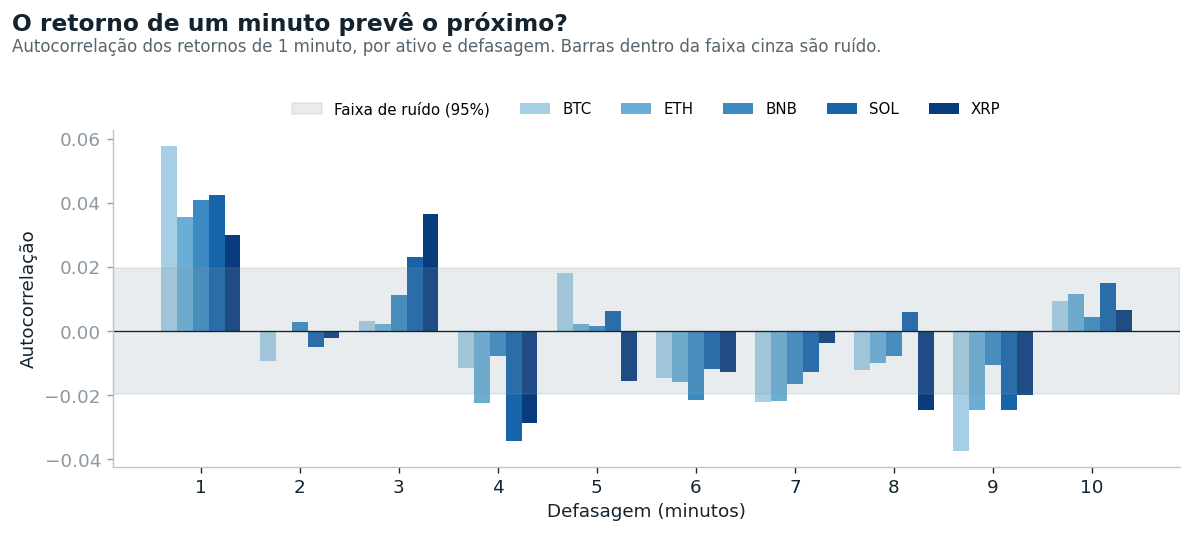

In [9]:
retornos = {a: np.log(d["close"]).diff().dropna() for a, d in dados.items()}
lags = range(1, 11)
autocorr = pd.DataFrame({a: [r.autocorr(lag) for lag in lags] for a, r in retornos.items()}, index=lags)
faixa = 1.96 / math.sqrt(min(len(r) for r in retornos.values()))
display(autocorr.style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(10, 4.5))
largura = 0.8 / len(ATIVOS)
for i, ativo in enumerate(ATIVOS):
    ax.bar(np.array(list(lags)) + (i - len(ATIVOS) / 2 + .5) * largura, autocorr[ativo],
           width=largura, label=ativo.replace("USDT", ""),
           color=plt.cm.Blues(0.35 + 0.6 * i / max(1, len(ATIVOS) - 1)))
ax.axhspan(-faixa, faixa, color=COR_NEUTRA, alpha=.18, label="Faixa de ruído (95%)")
ax.axhline(0, color=COR_TEXTO, lw=.8)
ax.set_xticks(list(lags))
ax.set_xlabel("Defasagem (minutos)")
ax.set_ylabel("Autocorrelação")
ax.legend(ncol=6, fontsize=9, frameon=False, loc="lower center", bbox_to_anchor=(.5, 1.0))
fig.suptitle("O retorno de um minuto prevê o próximo?", x=0.01, ha="left",
             fontsize=14, fontweight="bold", color=COR_TEXTO)
fig.text(0.01, 0.905, "Autocorrelação dos retornos de 1 minuto, por ativo e defasagem. Barras dentro da faixa cinza são ruído.",
         fontsize=10, color="#56656E")
fig.tight_layout()
fig.subplots_adjust(top=0.76)
fig.savefig(PASTA_IMAGENS / "autocorrelacao.png")
plt.show()

## 9. Conclusão
A célula abaixo resume os resultados e gera o `README.md` do repositório com os números desta execução.

In [10]:
def pct(x):
    return f"{x * 100:.1f}%".replace(".", ",")


def inteiro(n):
    return f"{n:,}".replace(",", ".")


regras_reais = resultados[resultados["regra"] != "Aleatório (controle)"]
vencedoras = regras_reais[regras_reais["acima_do_acaso"]]
perdedoras = regras_reais[regras_reais["significativo"] & (regras_reais["taxa"] < 0.5)]
estaveis = walk[(walk["estavel_acima_50"]) & (walk.index != "Aleatório (controle)")].index.tolist()
brier_reais = brier[brier["regra"] != "Aleatório (controle)"]
brier_bons = brier_reais[brier_reais["melhor_que_50"]]
fora_da_faixa = int((autocorr.abs() > faixa).sum().sum())
total_coef = autocorr.size
total_candles = sum(len(d) for d in dados.values())
inicio = min(d["abertura"].min() for d in dados.values())
fim = max(d["abertura"].max() for d in dados.values())
faixa_taxas = (regras_reais["taxa"].min(), regras_reais["taxa"].max())

controle = resultados[resultados["regra"] == "Aleatório (controle)"]
controle_txt = ", ".join(f"{pct(r.taxa)} ({r.horizonte} candle{'s' if r.horizonte > 1 else ''})" for r in controle.itertuples())

if vencedoras.empty:
    veredito = ("**Nenhuma regra acertou mais do que o acaso** de forma estatisticamente significativa. "
                f"As taxas de acerto ficaram entre {pct(faixa_taxas[0])} e {pct(faixa_taxas[1])}, "
                "e os intervalos de confiança praticamente se sobrepõem aos 50% de um cara ou coroa.")
else:
    nomes = ", ".join(f"{r.regra} ({r.horizonte} candle{'s' if r.horizonte > 1 else ''}: {pct(r.taxa)})"
                      for r in vencedoras.itertuples())
    so_curto = set(vencedoras["horizonte"]) == {min(HORIZONTES)}
    veredito = (f"**{len(vencedoras)} de {len(regras_reais)} combinações** ficaram acima do acaso com significância "
                f"estatística: {nomes}. "
                + (f"A vantagem é pequena e **desaparece quando a previsão é de {max(HORIZONTES)} candles**, "
                   "o que sugere um efeito de curtíssimo prazo, de um minuto para o seguinte, "
                   "e não um poder de previsão duradouro dos padrões. " if so_curto else
                   "A vantagem é pequena. ")
                + "Uma diferença desse tamanho também precisaria ser comparada com os custos de operação "
                  "(taxas e spread) antes de ter qualquer valor prático.")

linhas_tabela = "\n".join(
    f"| {r.regra} | {r.horizonte} | {inteiro(r.sinais)} | {pct(r.taxa)} | {pct(r.ic_inf)} a {pct(r.ic_sup)} | {r.p_valor:.4f} |".replace(f"{r.p_valor:.4f}", f"{r.p_valor:.4f}".replace(".", ","))
    for r in resultados.itertuples())

readme = f"""# 📈 Padrões de candles preveem o preço no curto prazo?

Estudo estatístico com **{inteiro(total_candles)} candles reais de 1 minuto** de {len(ATIVOS)} criptomoedas ({", ".join(a.replace("USDT", "") for a in ATIVOS)}), coletados da API pública da Binance entre {inicio:%d/%m/%Y} e {fim:%d/%m/%Y}.

![Python](https://img.shields.io/badge/Python-3776AB?style=flat-square&logo=python&logoColor=white)
![Pandas](https://img.shields.io/badge/Pandas-150458?style=flat-square&logo=pandas&logoColor=white)
![NumPy](https://img.shields.io/badge/NumPy-013243?style=flat-square&logo=numpy&logoColor=white)
![SciPy](https://img.shields.io/badge/SciPy-8CAAE6?style=flat-square&logo=scipy&logoColor=white)
![Matplotlib](https://img.shields.io/badge/Matplotlib-11557C?style=flat-square)

---

## 📌 A pergunta

Padrões de candles e cruzamentos de médias móveis são muito usados para tentar prever o próximo movimento do preço. **Essas regras acertam a direção do preço mais do que o acaso?**

## 🧭 Contexto

Este estudo nasceu de um projeto anterior: um painel em JavaScript que eu construí para detectar padrões de candles em tempo real, com dados da Binance. Ao adicionar backtest e validação estatística ao painel, os resultados indicaram que os padrões não tinham poder de previsão confiável. Este repositório refaz essa investigação em Python, de forma reprodutível e com mais rigor.

## 🔬 Metodologia

1. **Coleta:** {inteiro(CANDLES_POR_ATIVO)} candles de 1 minuto por ativo, via API pública da Binance
2. **Regras testadas:** 6 padrões de candles (engolfo de alta e de baixa, martelo, estrela cadente, três soldados, três corvos), cruzamento de médias exponenciais 9/21 e um **grupo de controle aleatório**
3. **Backtest:** cada sinal é comparado com o preço {" e ".join(str(h) for h in HORIZONTES)} candles depois
4. **Intervalo de confiança de Wilson (95%)** para cada taxa de acerto
5. **Teste binomial com correção de Bonferroni**, porque testar {n_testes} combinações ao mesmo tempo aumenta a chance de "achados" por sorte
6. **Validação walk-forward:** a taxa de acerto em 3 períodos cronológicos separados
7. **Brier score fora da amostra:** a "confiança" estimada na 1ª metade dos dados é avaliada na 2ª metade
8. **Autocorrelação dos retornos** de 1 minuto, para medir se o preço tem "memória"

## 📊 Resultados

![Taxa de acerto por regra](imagens/taxa_acerto.png)

| Regra | Horizonte (candles) | Sinais | Taxa de acerto | IC 95% (Wilson) | p-valor |
|---|:---:|---:|:---:|:---:|:---:|
{linhas_tabela}

Nível de significância após a correção de Bonferroni: **{f"{alfa_corrigido:.4f}".replace(".", ",")}**.

### Estabilidade ao longo do tempo
![Validação walk-forward](imagens/walk_forward.png)

{"Nenhuma regra ficou acima de 50% nos três períodos." if not estaveis else "Regras acima de 50% nos três períodos: " + ", ".join(estaveis) + "."}

### O preço tem memória?
![Autocorrelação dos retornos](imagens/autocorrelacao.png)

{fora_da_faixa} de {total_coef} coeficientes de autocorrelação ficaram fora da faixa de ruído. {"Na prática, o retorno de um minuto quase não ajuda a prever o seguinte, um comportamento próximo de um passeio aleatório." if fora_da_faixa <= total_coef * 0.2 else "Há alguma dependência entre minutos consecutivos, que merece uma investigação mais aprofundada."}

### A "confiança" das regras tem valor?
{len(brier_bons)} de {len(brier_reais)} combinações tiveram Brier score fora da amostra melhor que 0,25 (o resultado de sempre dizer 50%). {"Ou seja: em pelo menos metade dos casos, a taxa de acerto histórica de uma regra não serviu como confiança útil para o futuro." if len(brier_bons) <= len(brier_reais) / 2 else "Na maioria dos casos, a taxa histórica funcionou como uma estimativa útil, ainda que com ganho pequeno."}

## ⚖️ Limitações

- **Período curto:** uma semana de dados. Um padrão que aparece em uma semana pode não se repetir em outras condições de mercado.
- **Ativos correlacionados:** as criptomoedas costumam se mover juntas, então os sinais dos 5 ativos não são totalmente independentes e os p-valores podem estar otimistas.
- **Grupo de controle:** o sorteio aleatório teve taxa de acerto de {controle_txt}, uma referência do quanto o acaso sozinho pode variar.

## ✅ Conclusão

{veredito}

O principal aprendizado é metodológico: **uma taxa de acerto que parece boa no gráfico pode ser só ruído**. Intervalo de confiança, correção para múltiplos testes, validação fora da amostra e um grupo de controle aleatório são o que separa um padrão real de uma coincidência.

> ⚠️ Este é um estudo estatístico para fins educacionais. Não é recomendação de investimento.

## ▶️ Como reproduzir

```bash
git clone https://github.com/AlessandroMaxv10/estudo-padroes-candles.git
cd estudo-padroes-candles
pip install -r requirements.txt
jupyter notebook estudo.ipynb
```

Os dados são baixados automaticamente da API pública da Binance (sem cadastro). Ao final, o notebook gera os gráficos e este README com os números da execução.

## 🛠️ Tecnologias

- **Python**, **Pandas** e **NumPy** — coleta, tratamento e backtest
- **SciPy** — teste binomial
- **Matplotlib** — gráficos
- **API pública da Binance** — dados de mercado

## 📚 O que aprendi

- Coletar dados de uma API REST com paginação e limite de requisições
- Desenhar um backtest sem usar informação do futuro
- Aplicar intervalos de confiança, testes de hipótese e correção de Bonferroni
- Validar resultados fora da amostra (walk-forward e Brier score)
- Usar um grupo de controle para não se enganar com padrões aleatórios

---

👤 **Alessandro José dos Santos** · [LinkedIn](https://www.linkedin.com/in/alessandro-jos%C3%A9-dos-santos-01b87a127) · [Portfólio](https://alessandromaxv10.github.io)
"""

if MODO_SIMULADO:
    print("Modo simulado: README não foi salvo (os números não são de dados reais).")
    Path("README_simulado.md").write_text(readme, encoding="utf-8")
else:
    Path("README.md").write_text(readme, encoding="utf-8")
    print("README.md gerado com os resultados desta execução.")

print()
print(veredito.replace("**", ""))

README.md gerado com os resultados desta execução.

3 de 14 combinações ficaram acima do acaso com significância estatística: Martelo (1 candle: 55,5%), Três soldados (1 candle: 53,5%), Três corvos (1 candle: 52,5%). A vantagem é pequena e desaparece quando a previsão é de 5 candles, o que sugere um efeito de curtíssimo prazo, de um minuto para o seguinte, e não um poder de previsão duradouro dos padrões. Uma diferença desse tamanho também precisaria ser comparada com os custos de operação (taxas e spread) antes de ter qualquer valor prático.
